# Intelligent Network Congestion Prediction & Adaptive Routing — Results

**What this is.** Six months of real traffic from the Internet2 Abilene backbone
(2004, 48,096 five-minute snapshots across 30 links) used to do two things:
classify how congested each link is, and reroute traffic with Dijkstra using edge
costs that rise with congestion, to pull load off the busiest links.

**What it found.** The routing half works and reduces peak utilisation on congested
periods. The prediction half does **not** beat a trivial "assume nothing changed"
baseline — reported here as measured rather than dressed up.

---

*This notebook displays results only. Every number below was computed and verified
in notebooks 01–08; nothing is recalculated here. It reads only committed artefacts,
so it runs on a fresh clone in seconds without running the pipeline first.*

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

PROJECT = Path.cwd().parent
RAW = PROJECT / "data" / "raw" / "abilene"
PROCESSED = PROJECT / "data" / "processed"
FIGURES = PROJECT / "figures"
FIGURES.mkdir(exist_ok=True)

# Everything below is a saved artefact - no pipeline is re-run.
routing = pd.read_csv(PROCESSED / "adaptive_routing_timeseries.csv",
                      parse_dates=["timestamp"])
per_link = pd.read_csv(PROCESSED / "adaptive_routing_per_link.csv")
horizons = pd.read_csv(PROCESSED / "horizon_fold_scores.csv")

print(f"routing series : {len(routing):,} timesteps  "
      f"({routing.timestamp.min():%Y-%m-%d} to {routing.timestamp.max():%Y-%m-%d})")
print(f"per-link table : {len(per_link)} links")
print(f"horizon scores : {len(horizons)} fold-horizon combinations")

routing series : 48,096 timesteps  (2004-03-01 to 2004-09-10)
per-link table : 30 links
horizon scores : 15 fold-horizon combinations


In [2]:
# Shared palette - colourblind-safe, used across every chart in the project.
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#c3c2b7"
INK, MUTED = "#0b0b0b", "#898781"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "font.size": 9, "legend.frameon": False,
})
print("style set")

style set


## 1. The network

Twelve routers, thirty directed links, drawn at their real geographic positions.
Almost every link is OC-192 (9.92 Gbps); the Atlanta–Indianapolis pair is OC-48
(2.48 Gbps), a quarter of the capacity, which matters later.

**Highlighted in blue** is the west-bound corridor
Chicago → Indianapolis → Kansas City → Denver → Sunnyvale → Los Angeles. Notebook 03
found this is where congestion concentrates: OSPF routes traffic down it while
parallel capacity sits nearly idle.

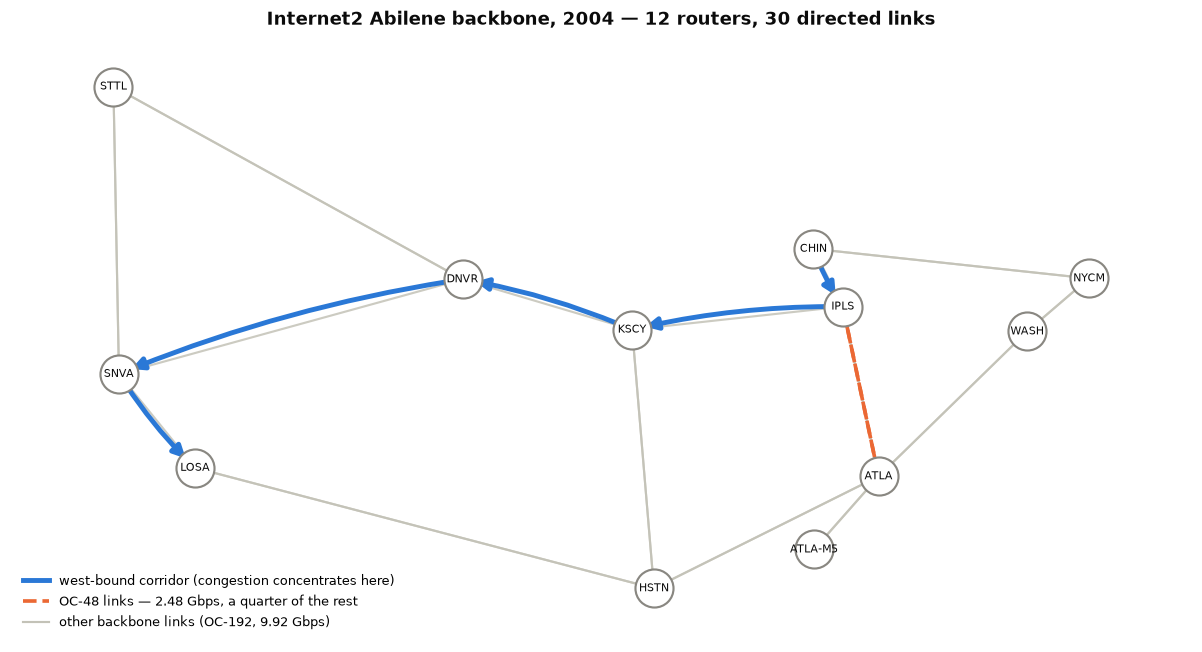

In [3]:
# Parse the committed topology file (nodes with coordinates, links with capacity).
nodes, edges, section = {}, [], None
for line in (RAW / "topo-2003-04-10.txt").read_text().splitlines():
    line = line.strip()
    if line in ("router", "link"):
        section = line
        continue
    if not line or line.startswith("#"):
        continue
    p = line.split()
    if section == "router":
        nodes[p[0]] = (float(p[3]), float(p[2]))          # (lon, lat)
    else:
        edges.append((p[0], p[1], float(p[2])))

# ATLA-M5 shares coordinates with ATLAng (same site) - nudge it so both are visible.
nodes["ATLA-M5"] = (nodes["ATLA-M5"][0] - 3.2, nodes["ATLA-M5"][1] - 2.6)

CORRIDOR = [("CHINng", "IPLSng"), ("IPLSng", "KSCYng"), ("KSCYng", "DNVRng"),
            ("DNVRng", "SNVAng"), ("SNVAng", "LOSAng")]

graph = nx.DiGraph()
for a, b, cap in edges:
    graph.add_edge(a, b, capacity=cap)

fig, ax = plt.subplots(figsize=(11, 6))
corridor_set = set(CORRIDOR)
others = [e for e in graph.edges() if e not in corridor_set]

nx.draw_networkx_edges(graph, nodes, edgelist=others, ax=ax,
                       edge_color=GREY, width=1.4, arrows=False, alpha=0.85)
nx.draw_networkx_edges(graph, nodes, edgelist=CORRIDOR, ax=ax,
                       edge_color=BLUE, width=3.2, arrows=True,
                       arrowsize=16, arrowstyle="-|>",
                       connectionstyle="arc3,rad=0.06")
nx.draw_networkx_nodes(graph, nodes, ax=ax, node_size=620,
                       node_color="white", edgecolors=MUTED, linewidths=1.4)
nx.draw_networkx_labels(graph, nodes, ax=ax, font_size=7.5, font_color=INK,
                        labels={n: n.replace("ng", "") for n in graph.nodes()})

# Mark the two low-capacity links, which cause a failure mode in notebook 08.
oc48 = [(a, b) for a, b, cap in edges if cap < 9_000_000]
nx.draw_networkx_edges(graph, nodes, edgelist=oc48, ax=ax,
                       edge_color=ORANGE, width=2.4, arrows=False, style="dashed")

ax.plot([], [], color=BLUE, linewidth=3.2, label="west-bound corridor (congestion concentrates here)")
ax.plot([], [], color=ORANGE, linewidth=2.4, linestyle="dashed", label="OC-48 links — 2.48 Gbps, a quarter of the rest")
ax.plot([], [], color=GREY, linewidth=1.4, label="other backbone links (OC-192, 9.92 Gbps)")
ax.legend(loc="lower left", fontsize=8.5)

ax.set_title("Internet2 Abilene backbone, 2004 — 12 routers, 30 directed links")
ax.set_axis_off()
plt.tight_layout()
fig.savefig(FIGURES / "01_topology.png")
plt.show()

## 2. Six months of traffic

Peak link utilisation at every 5-minute interval. Grey bands are periods with no
data — the 24 weekly source files are not contiguous.

Two episodes stand out, and notebook 03 traced both to their cause in the raw
origin–destination data:

- **April–May** — a west-bound surge driven by two large one-way transfers
  (`CHINng→HSTNng` and `CHINng→LOSAng`, each over 5 Gbps, 150–575× their normal level)
- **September** — a smaller east-bound episode, elevated egress from Seattle spread
  across several destinations

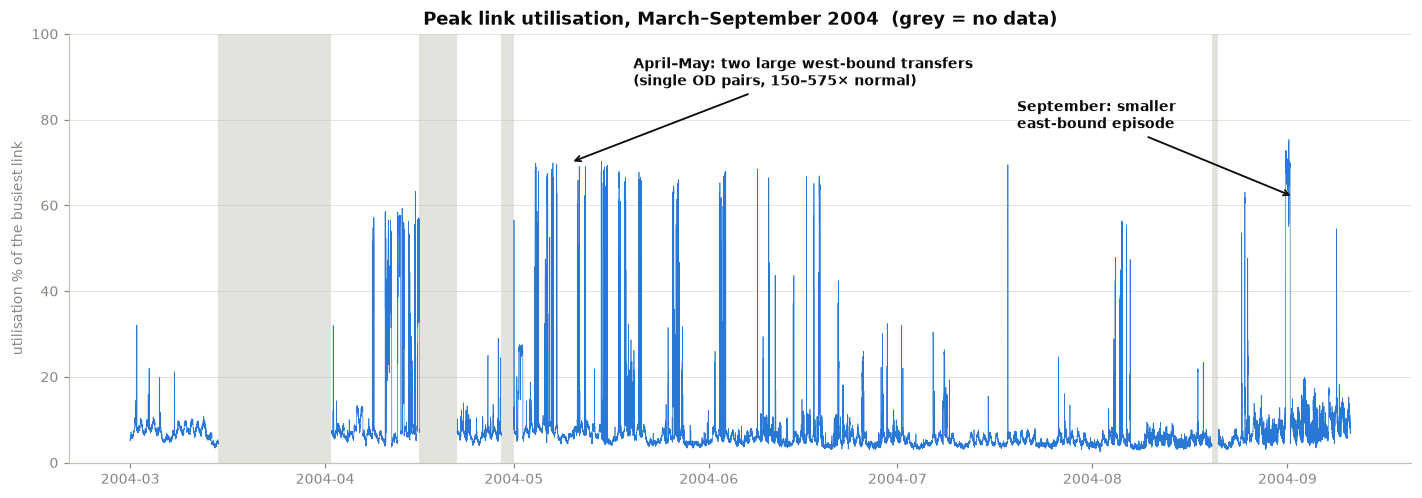

series peak : 75.36%
median      : 5.84%   (the backbone was heavily over-provisioned)


In [4]:
# Plot on a complete 5-minute grid so data gaps appear as breaks, not fake lines.
series = routing.set_index("timestamp")["peak_ospf"]
grid = series.reindex(pd.date_range(series.index.min(), series.index.max(), freq="5min"))

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(grid.index, grid.to_numpy(), color=BLUE, linewidth=0.45)

for start, end in [("2004-03-15", "2004-04-01"), ("2004-04-16", "2004-04-21"),
                   ("2004-04-29", "2004-04-30"), ("2004-08-20", "2004-08-20")]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end) + pd.Timedelta(days=1),
               color=GREY, alpha=0.45, linewidth=0)

ax.annotate("April–May: two large west-bound transfers\n(single OD pairs, 150–575× normal)",
            xy=(pd.Timestamp("2004-05-10"), 70), xytext=(pd.Timestamp("2004-05-20"), 88),
            color=INK, fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=INK, linewidth=1.2))
ax.annotate("September: smaller\neast-bound episode",
            xy=(pd.Timestamp("2004-09-02"), 62), xytext=(pd.Timestamp("2004-07-20"), 78),
            color=INK, fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=INK, linewidth=1.2))

ax.set_ylim(0, 100)
ax.set_ylabel("utilisation % of the busiest link")
ax.set_title("Peak link utilisation, March–September 2004  (grey = no data)")
ax.grid(True, axis="y")
plt.tight_layout()
fig.savefig(FIGURES / "02_utilisation_timeline.png")
plt.show()

print(f"series peak : {routing.peak_ospf.max():.2f}%")
print(f"median      : {routing.peak_ospf.median():.2f}%   "
      "(the backbone was heavily over-provisioned)")

## 3. Congestion prediction — the honest result

An XGBoost classifier predicts each link's congestion class (Low / Medium / High /
Critical) from its own recent history and the time of day, across five
time-ordered cross-validation folds.

Measured against **always predict the most common class**, it looks strong. Measured
against **persistence** — "assume the link is still in whatever class it was in at
the last reading", which requires no model at all — it does **not** win, at any
prediction horizon tested. The gap widens as the horizon grows.

This is reported as found. Notebook 07 tested the obvious follow-up (letting the
model see neighbouring links) and found congestion does not propagate along paths —
adjacent links peak at **lag 0**, so a neighbour is a redundant copy rather than an
early warning.

           model  persistence   naive  model − persistence
lead_min                                                  
5         0.8065       0.8150  0.1882              -0.0085
15        0.7268       0.7371  0.1882              -0.0103
30        0.6791       0.6948  0.1882              -0.0157


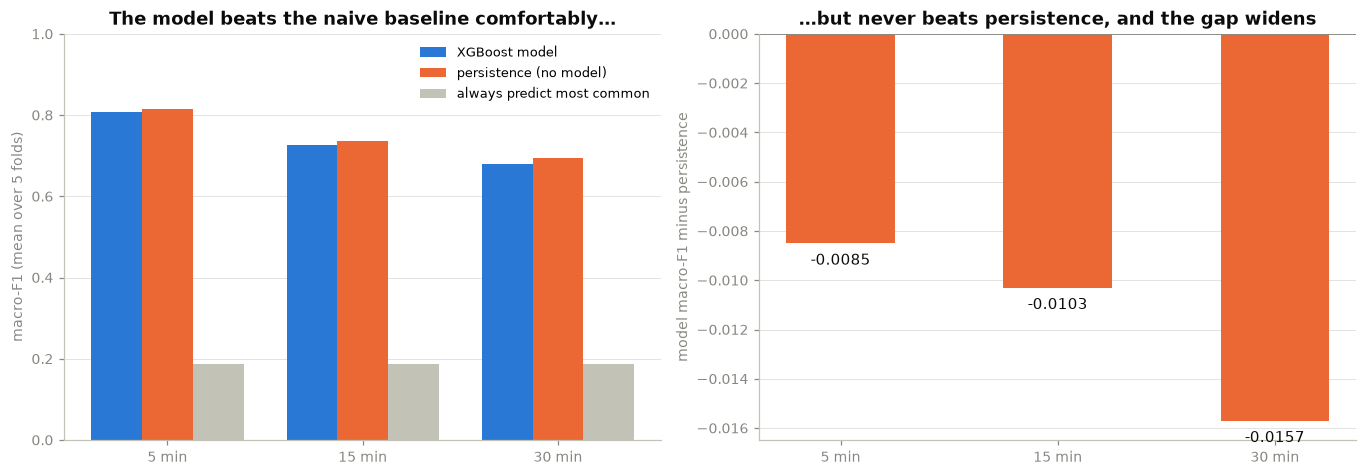

In [5]:
summary = horizons.groupby("lead_min").agg(
    model=("macro_F1", "mean"),
    persistence=("persist_macro_F1", "mean"),
    naive=("naive_macro_F1", "mean"),
).round(4)
summary["model − persistence"] = (summary.model - summary.persistence).round(4)
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
leads = summary.index.to_numpy()
x, w = np.arange(len(leads)), 0.26

axes[0].bar(x - w, summary.model, w, color=BLUE, label="XGBoost model")
axes[0].bar(x, summary.persistence, w, color=ORANGE, label="persistence (no model)")
axes[0].bar(x + w, summary.naive, w, color=GREY, label="always predict most common")
axes[0].set_xticks(x); axes[0].set_xticklabels([f"{l} min" for l in leads])
axes[0].set_ylabel("macro-F1 (mean over 5 folds)")
axes[0].set_ylim(0, 1)
axes[0].set_title("The model beats the naive baseline comfortably…")
axes[0].legend(fontsize=8.5)
axes[0].grid(True, axis="y")

gap = summary["model − persistence"].to_numpy()
axes[1].bar([f"{l} min" for l in leads], gap, color=ORANGE, width=0.5)
axes[1].axhline(0, color=MUTED, linewidth=1.2)
for i, v in enumerate(gap):
    axes[1].annotate(f"{v:+.4f}", xy=(i, v), xytext=(0, -14),
                     textcoords="offset points", ha="center", fontsize=9.5, color=INK)
axes[1].set_ylabel("model macro-F1 minus persistence")
axes[1].set_title("…but never beats persistence, and the gap widens")
axes[1].grid(True, axis="y")

plt.tight_layout()
fig.savefig(FIGURES / "03_model_vs_baselines.png")
plt.show()

## 4. Adaptive routing — before and after

Dijkstra with edge cost `w(e) / (1 − u(e))`: the link's real OSPF weight inflated by
the M/M/1 queueing-delay factor, so a busy link becomes expensive and traffic spills
onto idle capacity. It collapses to plain OSPF when the network is quiet, which is
most of the time.

Flows are assigned **one at a time, largest first**. An earlier version rerouted
everything simultaneously and drove peak utilisation to **290%** — every flow chose
the same newly-cheap path and collectively overloaded it, landing on the OC-48 link
marked in orange on the map above. That failure is kept in notebook 08.

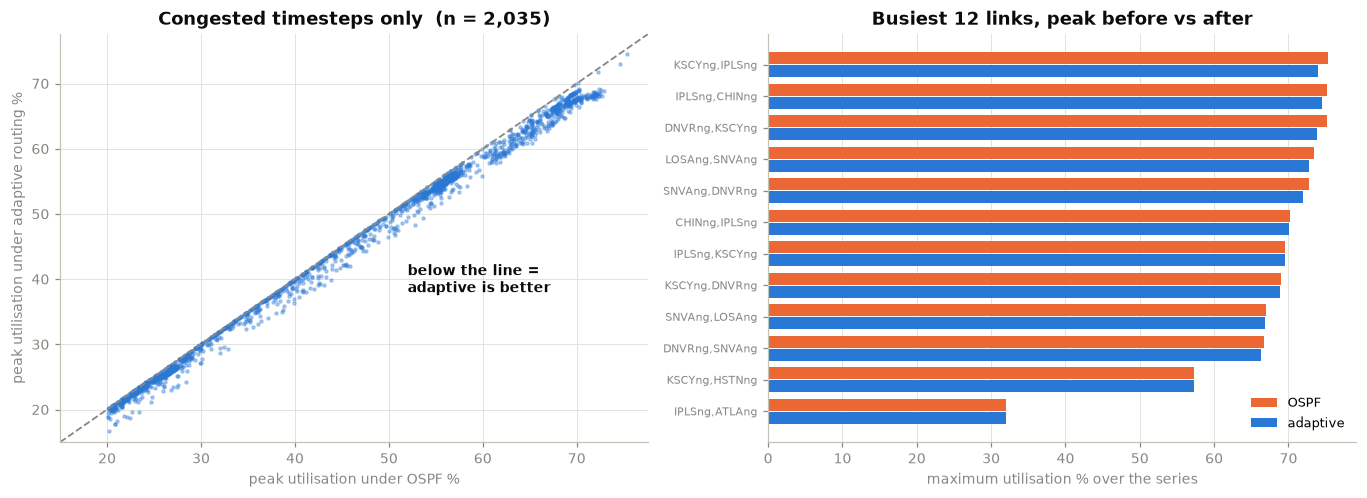

peak on congested timesteps : 44.79%  ->  43.72%   (-2.4%)
series peak                 : 75.36%  ->  74.48%
links pushed above capacity : 0


In [6]:
congested = routing.peak_ospf > 20
before, after = routing.loc[congested, "peak_ospf"], routing.loc[congested, "peak_adaptive"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

axes[0].scatter(before, after, s=4, color=BLUE, alpha=0.35)
lim = [15, max(before.max(), after.max()) * 1.03]
axes[0].plot(lim, lim, color=MUTED, linestyle="--", linewidth=1.2)
axes[0].annotate("below the line =\nadaptive is better", xy=(52, 38),
                 color=INK, fontsize=9, fontweight="bold")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("peak utilisation under OSPF %")
axes[0].set_ylabel("peak utilisation under adaptive routing %")
axes[0].set_title(f"Congested timesteps only  (n = {int(congested.sum()):,})")
axes[0].grid(True)

order = per_link.sort_values("max before", ascending=False).head(12)
y = np.arange(len(order))
axes[1].barh(y - 0.2, order["max before"], height=0.38, color=ORANGE, label="OSPF")
axes[1].barh(y + 0.2, order["max after"], height=0.38, color=BLUE, label="adaptive")
axes[1].set_yticks(y); axes[1].set_yticklabels(order["link"], fontsize=7)
axes[1].invert_yaxis()
axes[1].set_xlabel("maximum utilisation % over the series")
axes[1].set_title("Busiest 12 links, peak before vs after")
axes[1].legend(fontsize=8.5)
axes[1].grid(True, axis="x")

plt.tight_layout()
fig.savefig(FIGURES / "04_routing_before_after.png")
plt.show()

print(f"peak on congested timesteps : {before.mean():.2f}%  ->  {after.mean():.2f}%"
      f"   ({(after.mean()/before.mean()-1)*100:+.1f}%)")
print(f"series peak                 : {routing.peak_ospf.max():.2f}%  ->  "
      f"{routing.peak_adaptive.max():.2f}%")
print(f"links pushed above capacity : "
      f"{int((per_link['max after'] > 100).sum())}")

### Why the improvement is 2.4% and not more

At the busiest moment, **a single origin–destination flow carries 5.71 Gbps — 57% of
all traffic on the entire network, and 57.6% of a 9.92 Gbps link on its own.**
Single-path routing has to place that whole flow on one path, so every link it
crosses sits above 57.6% no matter what the cost function says.

The remaining headroom is the ~18% of other traffic sharing those links, and that is
what the 2.4% comes from. Going meaningfully lower needs **flow splitting**
(ECMP / MPLS-TE) — a different mechanism, not a better metric. Identifying that
binding constraint is the more useful result than the percentage itself.

## Summary

| | |
|---|---|
| **Data** | Internet2 Abilene backbone, Mar–Sep 2004 — 48,096 five-minute snapshots, 30 links, real OC-192/OC-48 capacities and real OSPF weights |
| **Peak utilisation reduced** | **2.4%** on congested periods (44.79% → 43.72%); series peak 75.36% → 74.48% |
| **Congestion classifier** | macro-F1 0.81 at 5 min — beats the naive baseline (0.19) but **not** persistence (0.82) |
| **Binding constraint found** | one OD flow = 57% of all network traffic, imposing a hard floor on any single-path scheme |

**Full pipeline, every verification step, and the reasoning behind each decision —
including the approaches that failed — are in notebooks 01–08 and the
[README](../README.md).**

In [7]:
print("figures written for the README:")
for f in sorted(FIGURES.glob("*.png")):
    print(f"  {f.name:<34}{f.stat().st_size/1000:6.0f} KB")

figures written for the README:
  01_topology.png                      114 KB
  02_utilisation_timeline.png          110 KB
  03_model_vs_baselines.png             63 KB
  04_routing_before_after.png          139 KB
